 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Steven James                <br>
Student Number : L00196960        <br>
Due Date       : 12/05/26                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## Project Overview 

As I have a hobby making learning tools for fun to use with my daughter, this project provides a way for a parent to improve reading, phonics, engagement, and bonding in a positive way.

A parent takes a few photos of pages from a kids’ book they are reading together. The system then turns those pages into a fun learning activity, boosting phonics and reading engagement by identifying words and objects on the pages and creating engaging questions such as “Where is this object?”, “What sound does the object begin with?”, or other simple questions about the text.

This system is designed for parent and child interaction in the early reading days. It shows the photos with helpful highlights and links each question back to the right page.

This makes ordinary story time into a fun learning and bonding period.

## Approach

We will adopt an incremental approach. Working this way we break the project down and each step has a clear outcome so we are focused. This makes the whole notebook easier to read, test and improve later on.

Each code step will carefully encapsulate its internal details. keeping the cells loosely coupled by passing only a high-level data object called the context between them. This context acts as a clean interface that carries everything needed from one step to the next and helps to manage the incurments.

We map here the overall processing pipeline the main sections of this notebook, and we will perfrom 6 main incruments, breaking down the system into elements more easy to manage. Within each increment multiple sub steps maybe perfomed. We also cant rule out that a future cell impacts prior. 

1. **Loading the photos** and **Image preprocessing** are handled under the Vision section.  
2. **Text extraction** and **Text processing and analysis** are handled under the NLP section.  
3. **Image feature detection and segmentation** continues in the Vision section.  
4. **Linking, question generation and final output** are handled in the Multi-modal section.


## Technology Stack 

Apart from standard Python 3 we use 

1. Image preprocessing using pillow and OpenCV
2. Text extraction with Tesseract OCR installed locally via pytesseract
3. Text processing and analysis using spacy
4. Image feature detection and segmentation with OpenCV


## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
pip install pillow opencv-python numpy matplotlib pytesseract

Note: you may need to restart the kernel to use updated packages.


## Imports

In [4]:
from PIL import Image
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Support Functions

## The Shared Context

Our context object contains all the data and possibly functions so we define as Python object. This allows us to refactor as we go through each iteration adding only what is needed. 

NOTE: Set CONST_DIR to the dir where your photos are 

TODO: 
Error handling array index bounds etc

In [8]:

CONST_DIR = r"C:\Users\aifor\AI_POSTGRAD\BDARCH\test_photos"
CONST_TRACE = True
#constants to index the source and grey image in PIL
CONST_PIL_SOURCE = "source"
CONST_PIL_GREY = "grey"
#define a page class to improve teh decoupling and keep stage processing results 
#Page class
class Page:
    def __init__(self, filename , photo):
        self.filename = filename
        self.source = photo
        #this is to help the parent locate as many kids books lack page numbers!
        self.page_anchor = []
        # dictionary so we can store stage results for debuging or other unkowns yet 
        self.stages = {}
        trace_print("Page created")
        
    def add_stage(self, stage_name, data):
        self.stages[stage_name] = data    
        trace_print(f"added stage {stage_name}")  
        
    def get_stage(self, index : str):
        # Returns the process step image asscoiated to an index 
        #see PIL consts
        trace_print(f"looiking for {index}")
        page = self.pages[index]
        if page:
            return page
        return None

# Context - central data object used by all steps
class Context:
    def __init__(self):
        self.photo_folder = None      # folder containing the photos
        self.pages =  []              #page objects see above def
    
    #note defult is source 
    def add_page(self, filename, image, index = CONST_PIL_SOURCE):
        self.pages.append( Page(filename, image) )
    
    def get_no_pages(self):
        return len(self.pages)
    

    
# Create the shared context
context = Context()
#README: note set the dir here where your files are 
context.photo_folder = CONST_DIR
if not os.path.exists(context.photo_folder):
    print(f"STOP: You have no directory {context.photo_folder} please create and add files")

In [9]:
def trace_print(text):
    if CONST_TRACE:
        print(f"{text}")

# NLP

## Load the photos 



In [10]:
if 'context' in globals() and context is not None:
    #get all photos from the folder we only care about typical image files 
    photos = [f for f in os.listdir(context.photo_folder) 
               if f.lower().endswith(('.png', 
                                      '.jpg', 
                                      '.jpeg'))
               ]
    # add each file to its context 
    if len(photos) > 0 :
        print(f"Found {len(photos)} photos")
        # Sort files by creation time, newest first 
        photos.sort(key=lambda f: os.path.getctime(os.path.join(context.photo_folder, f)))
        for filename in photos:
            path = os.path.join(context.photo_folder, filename)
            img = Image.open(path)
            context.add_page(filename, img)
            trace_print(f"adding {filename} to context")
        trace_print("Context updated with images")
    else:
        print(f"No photos/images to process have you added any to {context.photo_folder}")
else:
    print("Context is not set did you run the whole lab?")

Found 1 photos
Page created
adding Screenshot 2026-04-06 213059.png to context
Context updated with images


Follwing https://medium.com/analytics-vidhya/enhance-a-document-scan-using-python-and-opencv-9934a0c2da3d the first thing we need to do is grayscale, removes noise, creates brightness values to help the letters stand out when applying thresholding (In L1 satelite imagry we wriite brighness tempreatures per pixel and various thresholds allow things like cloud tests). 


added stage grey
grayscaled page Screenshot 2026-04-06 213059.png


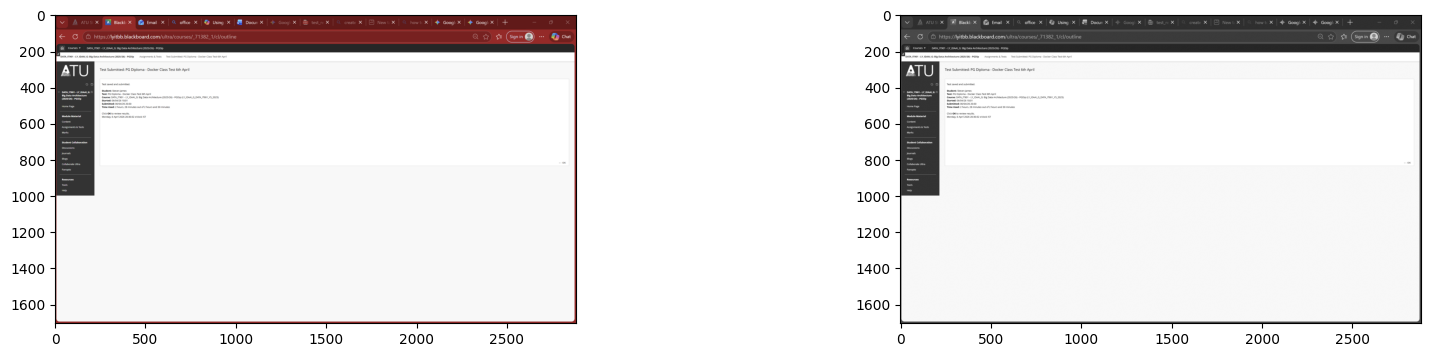

In [23]:
if 'context' in globals() and context is not None:      
    for page in context.pages:
        img_bgr = cv2.cvtColor(np.array(page.source), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        page.add_stage(CONST_PIL_GREY, gray)
        print(f"grayscaled page {page.filename}")
        if(trace_print):
            plt.figure(figsize=(20, 4))
            # the untouched photo 
            plt.subplot(1, 2, 1)
            plt.imshow(page.source)
            plt.subplot(1, 2, 2)
            plt.imshow(page.stages[CONST_PIL_GREY], cmap=CONST_PIL_GREY) 

else:
    print("Context is not set did you run the whole lab?")


In [ ]:
if 'context' in globals() and context is not None:
    
else:
    print("Context is not set did you run the whole lab?")

IndentationError: expected an indented block after 'if' statement on line 1 (4230818170.py, line 3)

# Vision

## Sub Heading 1

In [ ]:
# code here...

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code